In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy.stats import truncnorm
from scipy.stats import vonmises
from scipy.optimize import curve_fit

['ID', 'out']
(10, 100)


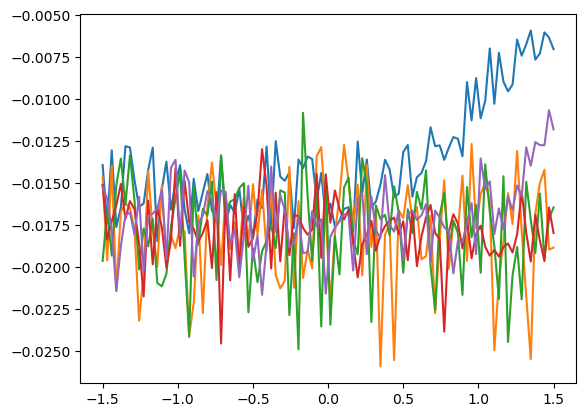

In [7]:
data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/lhc_batches/batch_80.npz")
print(data.files)
print(data["out"].shape)

vs = np.linspace(-1.5, 1.5, 100)
for i in range(5):
    plt.plot(vs, data["out"][i])

# 1.) Von-Mises with Beta

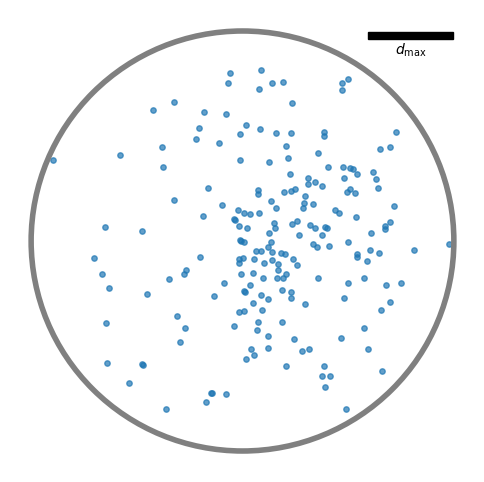

In [43]:
N = 200
R = 150
alpha = 0.5
beta = 5
mu = 0
kappa = 2

def Beta_von_Mises_component(alpha,
                             beta,
                             mu,
                             kappa,
                             radius,
                             N):
    
    u = np.random.beta(a=alpha, b=beta, size=N)
    r = radius*np.sqrt(u)

    theta = np.random.vonmises(mu=mu, kappa=kappa, size=N)

    sample = np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    
    return sample

def sample_from_Beta_von_Mises_mixture(alphas,
                                       betas,
                                       mus,
                                       kappas,
                                       weights,
                                       radius,
                                       N):
    
    cum_weight_sum = np.cumsum(weights)
    sample = []

    for _ in range(N):

        u = np.random.uniform(0., 1.)*cum_weight_sum[-1]
        component = np.searchsorted(cum_weight_sum, u)

        x = Beta_von_Mises_component(
            alpha=alphas[component],
            beta=betas[component],
            mu=mus[component],
            kappa=kappas[component],
            radius=radius,
            N=1
        )

        sample.append(x)

    return np.vstack(sample)

num_of_components = 1

alphas = [.8]#4.5*np.random.uniform(0, 1, N) + 0.5
betas = [2]#4.5*np.random.uniform(0, 1, N) + 0.5
mus = [0.0]#2*np.pi*np.random.uniform(0, 1, N)
kappas = 0.9*np.random.uniform(0, 1, N)

raw_weights = np.random.uniform(0, 1, num_of_components)
cum_weight_sum = np.cumsum(raw_weights)
weights = [w  / cum_weight_sum[-1] for w in raw_weights]

positions = sample_from_Beta_von_Mises_mixture(
    alphas,
    betas,
    mus,
    kappas,
    weights,
    R,
    N
)

with open("../../configs/acceptor_vonMises_beta.txt", "w") as f:
    for x in positions:
        f.write(f"{x[0]}\t{x[1]}\n")

scatter_args = {
    "s": 15.,
    "alpha": .7,
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(*positions.T, **scatter_args)
boundary = patches.Circle(xy=(0, 0), radius=R, fill=False, edgecolor="grey", lw=4)
ax.add_patch(boundary)
ax.axis('off')

scalebar = AnchoredSizeBar(
    ax.transData,
    size=60,
    label="$d_{\mathrm{max}}$",
    loc="upper right",
    pad=0.1, borderpad=1.5, sep=2, size_vertical=5,
    frameon=False,
    fill_bar=True
)

ax.add_artist(scalebar)

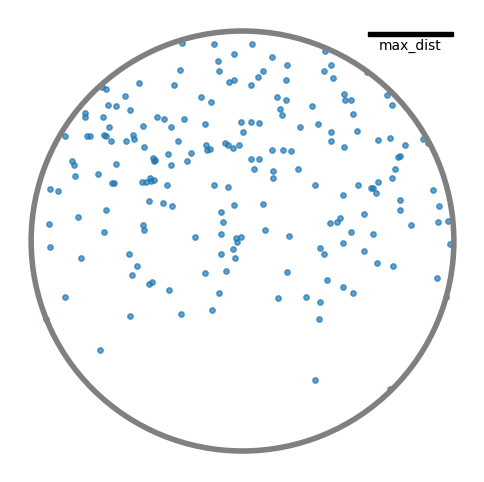

In [ ]:
def sample(means,
           covs,
           weights,
           radius,
           N):
    
    positions = []
    cum_sum_weights = np.cumsum(weights)

    while len(positions) < N:

        u = np.random.uniform(0.0, 1.0) * cum_sum_weights[-1]
        component = np.searchsorted(cum_sum_weights, u)

        x = np.random.multivariate_normal(mean=means[component], cov=covs[component])

        if np.sqrt(x[0]**2 + x[1]**2) < radius:

            positions.append(x) 
    
    return np.vstack(positions)

K = 5
radius = 150
n_acc = 200

R = np.sqrt(np.pi*radius**2 / n_acc)
radius_normalized = radius / R

std_min = radius / 3
std_max = radius / 2

log_bound_min = 2*np.log(std_min)
log_bound_max = 2*np.log(std_max)

means = []
covs = []
weights = []

raw_weights = []
for k in range(K):
    u = np.random.random(size=(1,))
    r = radius*np.sqrt(u)

    theta = 2*np.pi*np.random.random((1,))
    means.append(np.array([r*np.cos(theta), r*np.sin(theta)]).squeeze(-1))
    covs.append(np.exp((log_bound_max - log_bound_min)*np.random.random_sample() + log_bound_min) * np.eye(2))
    raw_weight = np.random.random()
    raw_weights.append(raw_weight)

raw_weight_sum = sum(raw_weights)
weights = [rw / raw_weight_sum for rw in raw_weights]

positions = sample(means, covs, weights, radius, 200)

scatter_args = {
    "s": 15.,
    "alpha": .7,
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(*positions.T, **scatter_args)
boundary = patches.Circle(xy=(0, 0), radius=radius, fill=False, edgecolor="grey", lw=4)
ax.add_patch(boundary)
ax.axis('off')

scalebar = AnchoredSizeBar(
    ax.transData,
    size=60,
    label="max_dist",
    loc="upper right",
    pad=0.1, borderpad=1.5, sep=2, size_vertical=2.5,
    frameon=False
)

ax.add_artist(scalebar)

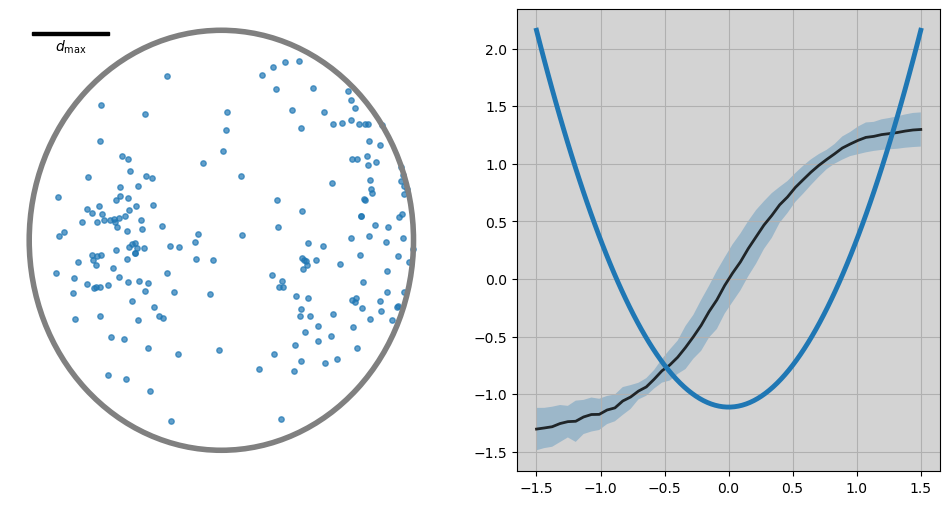

In [29]:
def target_function(x: np.array) -> np.array:

    target = x**2#1 / (1 + np.exp(4*x))

    return target

K = 5
radius = 150
n_acc = 200

R = np.sqrt(np.pi*radius**2 / n_acc)
radius_normalized = radius / R

trial = 9
sample = 3
data = np.loadtxt(f"../../data/experiment_0/trial_{trial}/acceptors_trial={trial}_sample={sample}")

data_normalized = np.array(data) / R

scatter_args = {
    "s": 15.,
    "alpha": .7,
}
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
#ax.scatter(data_normalized[:, 0], data_normalized[:, 1], **scatter_args)
ax[0].scatter(*data.T, **scatter_args)
boundary = patches.Circle(xy=(0, 0), radius=radius, fill=False, edgecolor="grey", lw=4)
ax[0].add_patch(boundary)
ax[0].axis('off')

iv_data = np.load(f"../../data/experiment_0/trial_{trial}/curves_trial={trial}.npz")
iv_curves = iv_data["outputs"]

normalized_iv_curves = (iv_curves - np.mean(iv_curves, keepdims=True, axis=1)) / np.std(iv_curves, keepdims=True, axis=1, ddof=1)
iv_curve_mean = normalized_iv_curves.mean(axis=0)
iv_curve_std = normalized_iv_curves.std(axis=0, ddof=1)

x = np.linspace(-1.5, 1.5, 100)
target = target_function(x)
normalized_target = (target - np.mean(target)) / np.std(target, ddof=1)
vs = np.linspace(-1.5, 1.5, 50)


num_of_curves = normalized_iv_curves.shape[0]

""" for c in range(num_of_curves):
    ax[1].scatter(vs, normalized_iv_curves[c, :]) """

ax[1].plot(vs, iv_curve_mean, alpha=.8, c="k", lw=2)
ax[1].fill_between(vs, iv_curve_mean-iv_curve_std, iv_curve_mean+iv_curve_std, alpha=.3)
ax[1].plot(x, normalized_target, lw=3.5)
ax[1].set_facecolor("lightgrey")
ax[1].grid(True)

scalebar = AnchoredSizeBar(
    ax[0].transData,
    size=60,
    label="$d_{\mathrm{max}}$",
    loc="upper left",
    pad=0.1, borderpad=1.5, sep=2, size_vertical=2.5,
    frameon=False
)

ax[0].add_artist(scalebar)

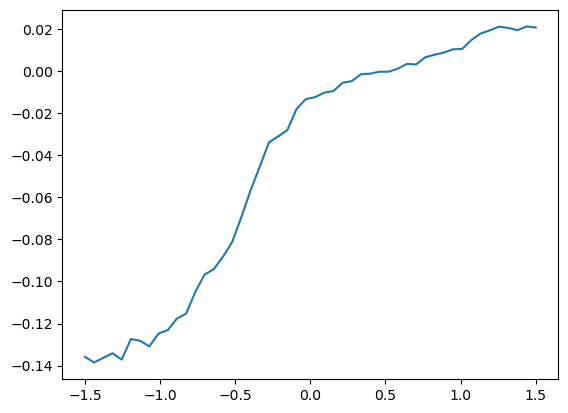

In [28]:
def mse(x: np.array, target: np.array) -> float:

    x_bar = np.mean(x, keepdims=True, axis=1)
    y_bar = np.mean(y)
    std_x = np.std(x, keepdims=True, axis=1, ddof=1)
    std_y = np.std(y, ddof=1)

    x_c = (x - x_bar) / std_x
    y_c = (y - y_bar) / std_y
    diff_sq = (y_c - x_c)**2
    mse = np.mean(diff_sq, axis=1)

    return mse

def target_function(x: np.array) -> np.array:

    target = 1 / (1 + np.exp(4*x))

    return target

x = np.linspace(-1.5, 1.5, 50)

data = np.load("../../data/iv_curves/data_point_400_acceptors.npz")

iv_curve = data["outputCurrent"]

vs = np.linspace(-1.5, 1.5, 50)

plt.plot(vs, iv_curve)

In [ ]:
def create_2d_mixture_of_truncated_gaussians(means: np.array, 
                                   covariance_matrices: np.array, 
                                   weights: np.array, 
                                   radius: float,
                                   N: int) -> np.array:
    
    cum_sum_weights = np.cumsum(weights)

    positions = []

    while len(positions) < N:

        u = np.random.uniform(0, 1) * cum_sum_weights[-1]
        component = np.searchsorted(cum_sum_weights, u)

        x = np.random.multivariate_normal(mean=means[component], cov=covariance_matrices[component])

        if np.sqrt(x[0]**2 + x[1]**2) < radius:

            positions.append(x)
    
    return positions

In [ ]:
means = np.array([[-0.4, -0.6], [0.2, 0.4], [0.5, -0.5]])
covariance_matrices = np.array([0.02*np.eye(2), 0.05*np.eye(2), 0.04*np.eye(2)])
weights = np.array([0.3, 0.3, 0.4])

pos = create_2d_mixture_of_truncated_gaussians(
    means==means,
    covariance_matrices=covariance_matrices,
    weights=weights,
    radius=1,
    N=10_000
)
pos_arr = np.array(pos)

plt.figure(figsize=(5, 5))
plt.scatter(pos_arr[:, 0], pos_arr[:, 1], s=2.5)